# 1.괴발 개발 손글씨 읽기 OCR 서비스
- 광학무자 인식 기술 Optical Character Recognition 개념, 시장성, 전망, 사례 소개 유스케이스 작성. 어플구현
## 1.1 개념, 사례
- 손글시 텍스트화  이미지 속 문자를 컴퓨터가 인식, 디지털 문자변환 기술. 
- 이미지의 일부. 텍스트로 번역, 스캔된 문서의내용 분석, 검색, 편집. => 음성정보로 변환 
- 패턴 인식 알고리즘 기반 OCR 기술, 언어종류, 폰트종류, 이미지왜곡, 스캔 해상도, 명암 변수 로 인식 오류 발생. 
- 전세계 OCR 시장 규모 185달러 2024기준, 
- 신용카드 촬영 - 자동 결제 정보란 입력 기능 , 영수증 인식 서비스 -> 정산 페이지 기록. 
- 구글 ocr 서비스 네이버 클로바 ocr api 제공. 
- 외국어 번역 앱서비스. 파파고, 
## 1.2 기술키워드 
- 인코더, 디코더 : 도메인간 변환, 다른 도메인간 변환에도 사용. 
- Caption generation . : 이미지 압축 모델 로 구성. 특징추출 차원축소 벡터 , 디코더는 문장생성 모델로 구성. 인코더의 저차원 벡터 표현을 입력받아 문장생성. 
- Seq2seq 모델 : 번역 
- 토크나이저 : 형태소단위 분리, 숫자데이터 변환 = 토큰(컴퓨터가 수치적 형태로 처리하고 이해가능)

## 1.3 서비스 기획
- 유스케이스 작성. 
     유스케이스 다이어그램 :
        - 시스템이 사용자에게 제공하는 특정 기능 , 서비스( 시방서), 사용자가 시스템과 상호작용 과정설명. 
        - 유스케이스들과 사용자 간 관계 시각적 표현, 시스템 개발 초기단계 요구사항 분석과 설계에 도움. 
        - 테스트 사례 작성, 사용자 메뉴얼 작성에도 활용 됨. 
    - 액터 :  시스템 사용자. 
    - 유스케이스: 시스템 제공 기능(타원)
    - 연관관계 : 관계(화살표 없는 실선)
    - 포함관계 : 다른유스케이스의 전제 조건 필요관계(<<포함>>
    - 일반화 관계 : 추상화된 유스케이스와 구체화된 유스케이스 간 관계 ( 실선 화살표)
> 2024.12.04
- 시나리오 요약 
    -> 사용자가 입력함.
        - 이미지 파일 업로드 방식. 
        - 캔버스에 직접 손글씨 쓰기 방식.
    -> 사전 학습 모델활용하여 입력받은 손글씨 이미지를 추론하여 택스트 추출 
    -> 변환된 텍스트를 화면에 출력
- 애플리케이션 구성 구체화 
    - 최종 사용자의 요구사항 명확, 화면 기능 검토 단계 
    1. 사용자 손글씨 입력용 UI( file upload type, canvers type)
    2. UI input => text transform ( 핵심 기능. model inference)
    3. UI output
- 머신러닝 플로우 
    1. 전처리(preprocess) : 데이터 형식, 크기 변환, 정규화, 토큰화, 자르기 회전반전, 증식등. 
    2. 모델 추론
    3. 후처리 (postprocess): 결과물을 실제 사용가능한 형태로 변환 

## 1.4 모델 선정
- 논문 서칭. 사전 학습 모델 활용-> 시간절약. , 자원절약(GPU 등 하드웨어 필요없음), 높은성능. 허깅페이스 이용
- https://huggingface.co -> computer vision -> image-to-text click -> handwritten-> microsoft/trocr-base-handwritten click
- TrOCR 모델 repository 이동, 2021.4 공개 모델. 인코더, 디코더 모델.  텍스트간 문자 오류 비율 지표 CER(Character Error Rate) 에서 높은 성능. 
- 관련논문  TrOCR: transformer-based optical character recognition with pre-trained models
- TrOCR  
    1. 손글씨 이미지 를 작은 부분으로 나눈 조각들인 이미지 패치(patch)를 입력 값으로 받음. 
    2. 인코더가 이미지 패치를 저차원 벡터변환( 임베딩화)
    3. 임베딩정보가 디코더의 입력됨. 
    4. 디코더가 임베딩정보를 바탕으로 텍스트 토큰을 순차적 출력, 시작토큰 (Begiining of sequence)를 시작으로 다음 토큰예측 마지막 토큰 까지 출력(End of sequence)

- 원하는 기능을 수행할 수잇는지, 입력할 데이터로 원하는 수준의 결과가나오는지(성능), 모델사용방법 을 파악. 
- 레포 [MOdel card ] 탭에 이론적 배경 설명 모델 구조, 사용법 결과 확인 

- 예제 이미지 다운 : https://github.com/MRSyee/dl_apps/tree/main/ocr/examples

## 1.5 model 실행하기 
- 코랩환경 필요 https://colab.research.google.com
- git hub tap -> https://github.com/MrSyee/dl_apps

> 2024.12.05
## 1.6 애플리케이션 구현하기 
- !pip install gradio  ## web 기반 gui 만들수 있는 라이브러리
- iamge file upload ui 구현
    1. 이미지 업로드
    2. convert button 
    3. 이미지에서 텍스트 출력
- gr.Image 객체 컴포넌트 추가. gr.Markdown : UI 마크 다운 문법 추가. 
- TrOCR 추론기 클래스 구현 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 16.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 13.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: tomlkit
    Found existing installation: tomlkit 0.11.1
    Uninstalling tomlkit-0.11.1:
      Successfully uninstalled tomlkit-0.11.1
  Attempting uninstall: python-multipart
    Found existing installation: python-multipart 0.0.9
    Uninstalling python-multipart-0.0.9:
      Successfully uninstalled python-multipart-0.0.9
  Attempting uninstall: starlette
    Found existing installation: starlette 0.37.2
    Uninstalling starlette-0.37.2:
      Successfully uninstalled starlette-0.37.2
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.23.3
    Uninstalling huggingface-hub-0.23.3:
      Successfully uninstalled huggingface-hub-0.23.3
  Attempting uninstall: fastapi
    Found existing installation: fastapi 0.111.0
    Uninstalling fastapi-0.111.0:
 

In [ ]:
# Basic
import sys,os ; sys.path.append("./../")
from DataPreprocessing_ import *
from Modeling import *
from DeepPreProcessing_ import *


DEEP_0_GPU_SETTING__macOS()

🥇 - torch , CUDA system check and model download
 📌 torch version : 2.5.1
 📌 torch  backend.mps is built : True
 📌 torch backend.mps is available : True
 📌 torch cuda is available: False
🥇 - Apple silicon user => Metal Performance Shaders 가속을 사용함. 
 - Using mps device
🥇 - pytorch mps 가속 불가능 발생경우 지원안되는 경우도 돌아게게끔 환경 설정함. 


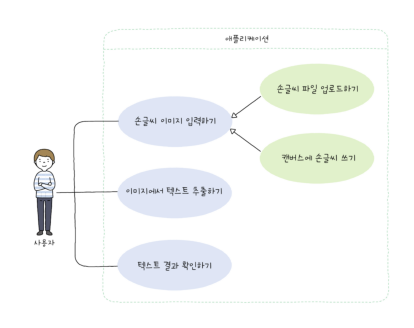

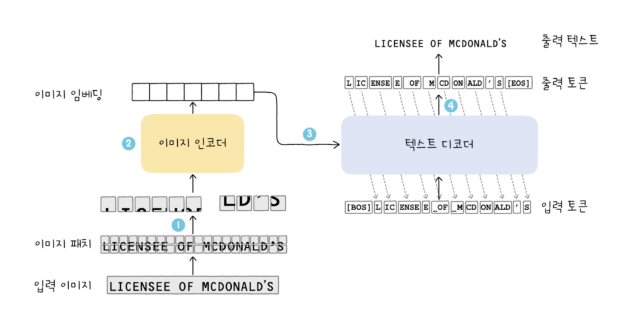

In [2]:
image_show('./usecase01.png')
image_show('./TrOCR_explain_01.png')

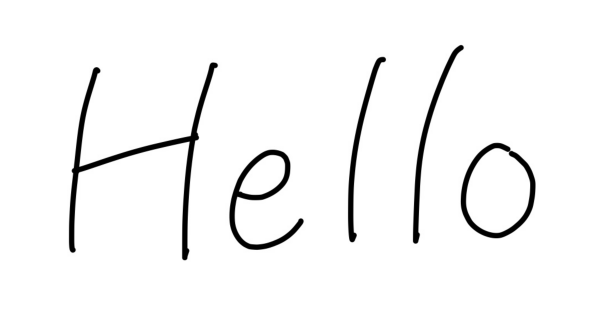

🥇[Info] load pretrained TrOCRProcessor
🥇[Info] load  pretrained VisionEncoder Decoder model


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Unused or unrecognized kwargs: return_tensor.


🥇pixel value tesor 변환
 -pixel_values shape: torch.Size([1, 3, 384, 384])
🥇 image to text 변환 결과 : Hello
process time : 10.3323 sec


In [ ]:
generated_text = DEEP_0_Image_to_TEXT(image_addr="./handwritten_image/Hello.png")

# Web 출력

Closing server running on port: 7863


In [ ]:
class TrOCRInferencer:
    """
    # # Image to text 
    ## inferencer = TrOCRInferencer()
    ## text = inferencer.inference(image)
    
    """
    
    def __init__(self):
        import warnings ; warnings.filterwarnings('ignore')
        
        from transformers import TrOCRProcessor , VisionEncoderDecoderModel
        print("[INFO] Initialize TrOCR Inferencer.")
        self.processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
        self.model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
    from PIL import Image
    def inference(self, image: Image)->str:
        """
        # Inference using model 
        ## - It is performed as a procedure of preprocessing -inference -postprocessing.
        """
        import torch
        
        ## Preprocessing
        pixel_values = self.processor(images=image, return_tensors = "pt").pixel_values
        
        if type(pixel_values)==type([]):
            y("pixel value tesor 변환")
            pixel_values = torch.tensor(pixel_values, dtype=torch.float32)

        print((f" -pixel_values shape: {pixel_values.shape}") )
        generated_ids = self.model.generate(pixel_values)
        generated_text = self.processor.batch_decode(
            generated_ids,skip_special_tokens = True
        )[0]
        
        return generated_text
    import numpy as np
    

In [ ]:
import gradio as gr
with gr.Blocks() as app:
    inferencer = TrOCRInferencer()
    
    gr.Markdown("# Handwritten Image OCR")
    image = gr.Image(label="Handwritten image file")
    output = gr.Textbox(label = "Output Box")
    convert_btn = gr.Button("Convert")
    import numpy as np
    def image_to_text(image: np.ndarray) -> str:
        from PIL import Image
        if type(image) ==type({}):
            print(" image 가 dict 타입입니다. ")
            def sketchToNumpy(image):
                imArray = (image['composite'])
                return imArray
            
            image = Image.fromarray(sketchToNumpy(image)).convert('RGB')

            text = inferencer.inference(image)
        else:
            image = Image.fromarray(image).convert('RGB')
            text = inferencer.inference(image)
        
        return text

    convert_btn.click(
        fn = image_to_text, inputs = image, outputs=output
    )
    sketchpad = gr.Sketchpad(
        label = "Handwritten Sketchpad",
        width =600,
        height=192,
    )
    ca_output = gr.Textbox(label= 'Canvas image to text output')            
    ca_convert_btn = gr.Button("Convert")
    ca_convert_btn.click(
        fn = image_to_text, inputs = sketchpad, outputs = ca_output
    )
    ## inline : 주피터 노트북 출력 셀에 ui 출력 할것인지 
app.launch(inline=True , share =True)

[INFO] Initialize TrOCR Inferencer.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


* Running on local URL:  http://127.0.0.1:7892
* Running on public URL: https://25ed89603b8f21455c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/gradio/queueing.py", line 624, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/gradio/route_utils.py", line 323, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/gradio/blocks.py", line 2039, in process_api
    inputs = await self.preprocess_data(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/gradio/blocks.py", line 1714, in preprocess_data
    raise InvalidComponentError(
gradio.exceptions.InvalidComponentError: <class 'gradio.interface.Interface'> Component not a valid input component.


In [65]:
app.close()

Closing server running on port: 7892
